# 01 - Data Ingestion and EDA

This notebook loads the open California Housing dataset, checks its shape and quality, and prepares the data for model training.

The dataset is loaded through scikit-learn, so a large dataset file does not need to be committed to GitHub.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing


## 1. Data Ingestion

In [2]:
dataset = fetch_california_housing(as_frame=True)

df = dataset.frame.copy()
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
df.info()

Rows: 20,640
Columns: 9
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


## 2. Basic Quality Checks

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


In [5]:
print("Missing values:")
print(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Duplicate rows: 0


## 3. Target Distribution

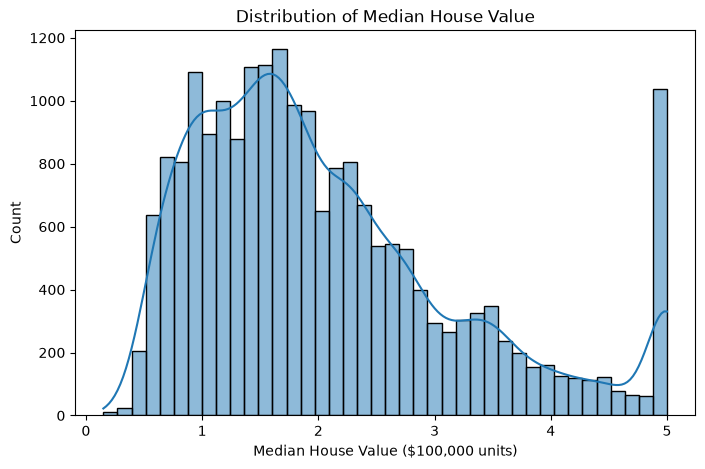

In [6]:
plt.figure(figsize=(8, 5))
sns.histplot(df["MedHouseVal"], bins=40, kde=True)
plt.title("Distribution of Median House Value")
plt.xlabel("Median House Value ($100,000 units)")
plt.show()

## 4. Feature Relationships

A quick correlation view helps understand which variables have stronger linear relationships with the target. This is exploratory analysis only; feature selection is not based on this plot alone.

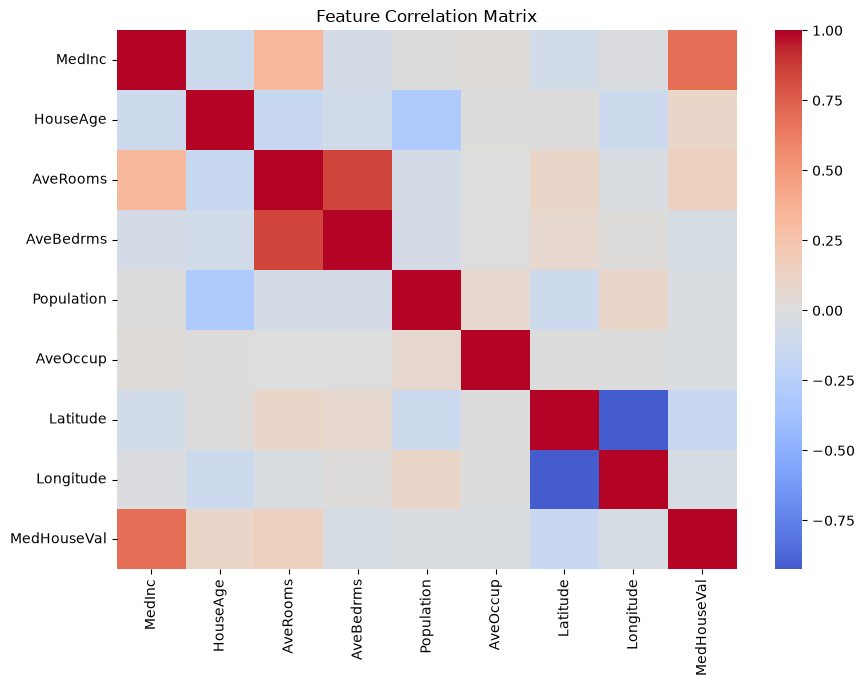

In [7]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.show()

## 5. Prepare X and y

The next notebook will create the train/test split and build the reproducible sklearn pipeline.

In [8]:
X = df.drop(columns="MedHouseVal")
y = df["MedHouseVal"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)


Feature shape: (20640, 8)
Target shape: (20640,)


### Conclusion

The dataset is compact enough for CPU-based training. No GPU is required, and the original dataset does not need to be stored in the repository.